# Akıllı Tarım: Toprak Verilerine Göre Ürün Önerisi (Sınıflandırma)

Bu proje, toprak değerlerine (N, P, K, pH vb.) ve iklim koşullarına bakarak en verimli ürünün ekilmesini amaçlamaktadır.

**Veri Seti Elde Etme:** Veri setini [Kaggle - Crop Recommendation Dataset](https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset) linkinden `Crop_recommendation.csv` olarak indirebilirsiniz. İndirdiğiniz dosyayı notebook ile aynı klasöre koymanız gerekmektedir.
**Problem:** Çiftçilerin toprak özelliklerine en uygun ürünü seçememesi verim kaybına yol açmaktadır.
**Motivasyon:** Makine öğrenimi kullanarak toprak kimyası ve iklim verileriyle en yüksek verimi verecek ürünü (label) tahmin etmek.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
RANDOM_STATE_VAL = 42 # Rastgele bölme işlemi için sabit bir değer
TEST_SIZE_RATIO = 0.20 # Verinin %20'si test için ayrılacak
DATA_PATH = 'Crop_recommendation.csv'

### Verinin Yüklenmesi
Pandas kütüphanesi kullanılarak CSV formatındaki veri seti projeye dahil edilir.

In [53]:
# Veri setini yüklüyoruz
df = pd.read_csv('Crop_recommendation.csv')
# Verinin ilk 5 satırını kontrol edelim
print("Veri başarıyla yüklendi. İşte ilk 5 satır:")
df.head()

Veri başarıyla yüklendi. İşte ilk 5 satır:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


### Keşifsel Veri Analizi (EDA)
Bu bölümde verinin istatistiksel özetini çıkarıp, özellikler arasındaki ilişkileri görselleştireceğiz.

In [54]:
# Verinin genel istatistiksel özeti
print("İstatistiksel Özet:")
display(df.describe())

# Eksik değer kontrolü
print("\nEksik Değer Sayısı:")
print(df.isnull().sum())

İstatistiksel Özet:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117



Eksik Değer Sayısı:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


### Hedef Değişken Dağılımı (Sınıf Dengesi)
Veri setimizdeki ürün sınıflarının (label) dengeli dağılıp dağılmadığını kontrol ediyoruz. Dengeli bir dağılım, modelin her ürün türünü eşit hassasiyetle öğrenmesi için önemlidir.

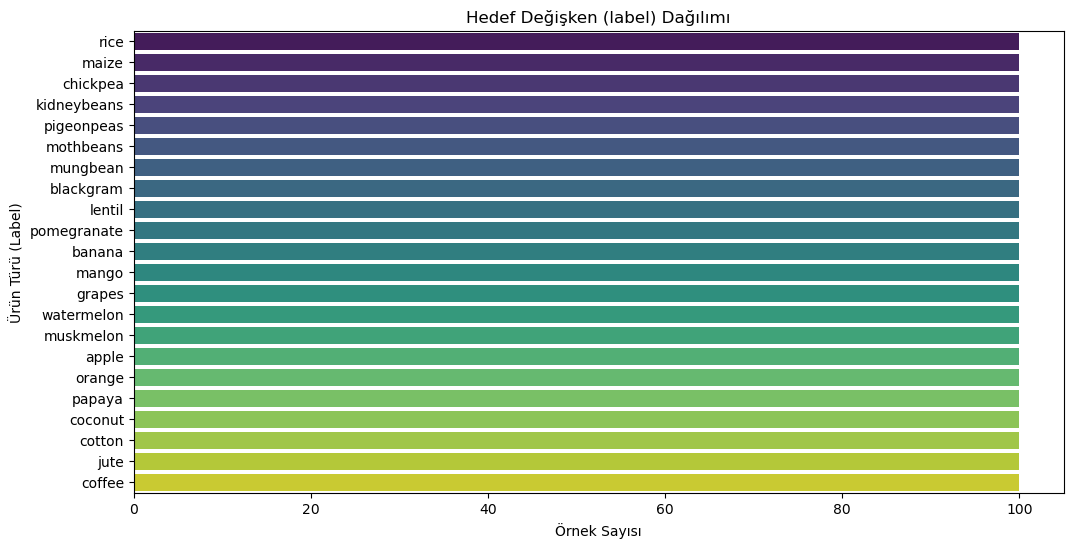

Sınıf Sayıları:
label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64


In [55]:
# Grafik boyutu için sabit değişken tanımlıyoruz (Gereksinim 5.2)
FIGURE_SIZE_LARGE = (12, 6)

def plot_class_distribution(data, target_column):
    """
    Veri setindeki hedef değişkenin dağılımını sütun grafiği ile görselleştirir.
    :param data: Pandas DataFrame
    :param target_column: Görselleştirilecek sütun adı
    """
    plt.figure(figsize=FIGURE_SIZE_LARGE)
    
    # Seaborn ile sınıfların sayısını görselleştiriyoruz
    sns.countplot(y=target_column, data=data, palette='viridis', hue=target_column, legend=False)
    
    plt.title(f'Hedef Değişken ({target_column}) Dağılımı')
    plt.xlabel('Örnek Sayısı')
    plt.ylabel('Ürün Türü (Label)')
    plt.show()

# Fonksiyonu çağırarak dağılımı görselleştiriyoruz
plot_class_distribution(df, 'label')

# Sayısal olarak da her sınıftan kaç tane olduğunu yazdıralım
print("Sınıf Sayıları:")
print(df['label'].value_counts())

Sınıf Dengesi: Hedef değişken dağılım grafiğinde görüldüğü üzere, veri setindeki 22 farklı ürünün her birinden tam olarak 100 adet örnek bulunmaktadır. Bu durum, veri setinin tamamen dengeli olduğunu ve modelin herhangi bir sınıfa karşı yanlılık (bias) göstermeyeceğini kanıtlar.

### Özelliklerin Birbirleriyle İlişkisi (Korelasyon)
Sayısal özelliklerin hedef değişken üzerindeki etkisini ve birbirleriyle olan bağını ısı haritası ile inceliyoruz.
P (Fosfor) ve K (Potasyum) arasında 0.74 gibi yüksek bir bağ var. Bu, toprakta fosfor arttıkça potasyumun da genelde yüksek olduğunu gösterir.

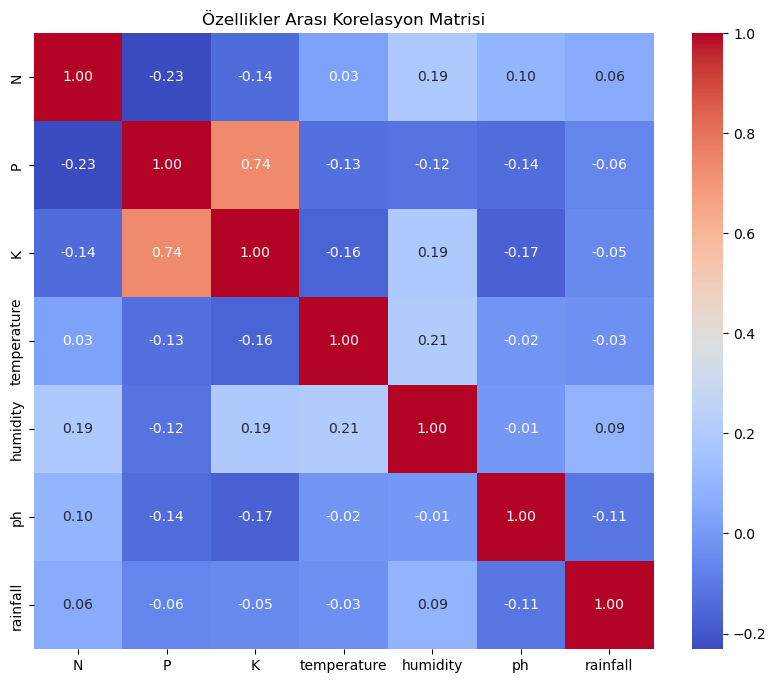

In [56]:
plt.figure(figsize=(10, 8))
# Sadece sayısal sütunlar için korelasyon hesaplıyoruz
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Özellikler Arası Korelasyon Matrisi')
plt.show()

Özellik İlişkileri (Korelasyon): Korelasyon matrisinde en dikkat çekici ilişki P (Fosfor) ve K (Potasyum) arasındadır (0.74). Bu güçlü pozitif bağ, toprakta bu iki elementin genellikle paralel miktarlarda bulunduğunu gösterir. Ayrıca N (Azot) ve P (Fosfor) arasında zayıf bir negatif ilişki (-0.23) saptanmıştır.

### Özelliklerin Dağılımı ve Aykırı Değer Analizi
Veri setindeki sayısal değişkenlerin (N, P, K, pH vb.) nasıl dağıldığını histogramlar ile inceliyoruz. Ayrıca boxplot kullanarak veride uç (aykırı) değerler olup olmadığını kontrol ediyoruz.

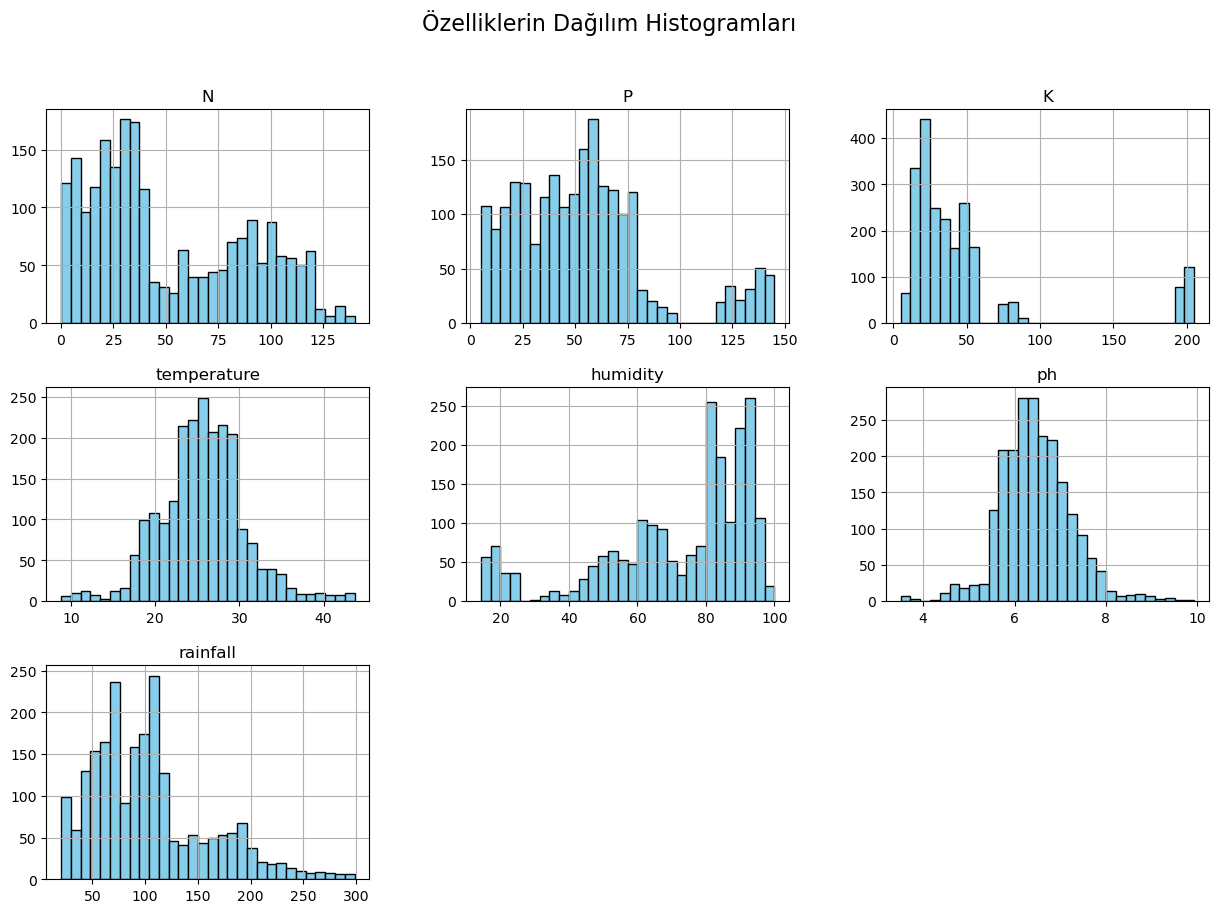

In [57]:
# Tüm sayısal sütunlar için histogram çizdiriyoruz
df.drop('label', axis=1).hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("Özelliklerin Dağılım Histogramları", fontsize=16)
plt.show()

Her bir değişkenin dağılımı incelendiğinde, pH değerinin normal dağılıma (çan eğrisi) oldukça yakın 
olduğu görülmüştür. Yağış ve nem verilerinde ise çok modlu dağılımlar gözlemlenmiştir. Bu, veri 
setindeki 22 farklı ürünün çok farklı iklim ihtiyaçlarına (kurakçıl ve nemcil bitkiler gibi) sahip 
olduğunun bir göstergesidir. 

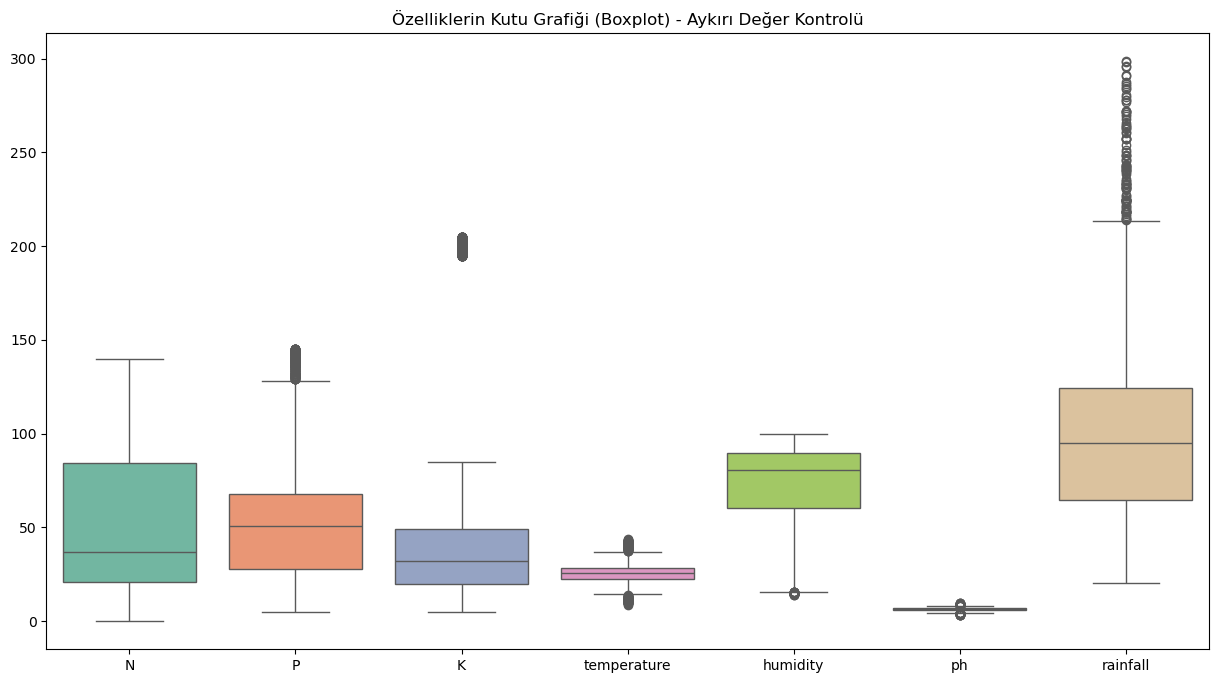

In [58]:
# Boxplot ile verinin yayılımını ve aykırı değerleri görüyoruz
plt.figure(figsize=(15, 8))
sns.boxplot(data=df.drop('label', axis=1), palette="Set2")
plt.title("Özelliklerin Kutu Grafiği (Boxplot) - Aykırı Değer Kontrolü")
plt.show()

Aykırı Değerler: Boxplot grafiği incelendiğinde, özellikle Potasyum (K) ve Yağış (Rainfall) değişkenlerinde çok sayıda aykırı (uç) değer gözlemlenmektedir. Bu durum, bazı özel ekinlerin (örneğin üzüm ve elma) çok yüksek potasyum veya su ihtiyacı duyduğunu göstermektedir.

### İki Özellik Arasındaki İlişkinin İncelenmesi (Scatter Plot)
Korelasyon matrisinde aralarında güçlü bağ saptanan değişkenlerin ürün bazlı dağılımını inceliyoruz. Bu grafik, ekinlerin hangi değer aralıklarında kümelendiğini (cluster) görmemizi sağlar.

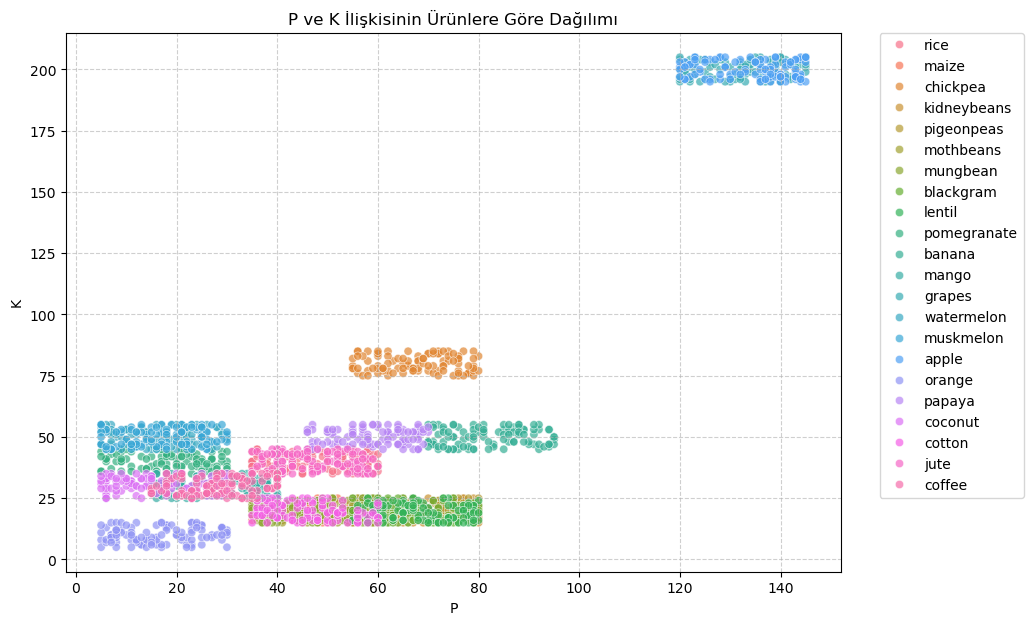

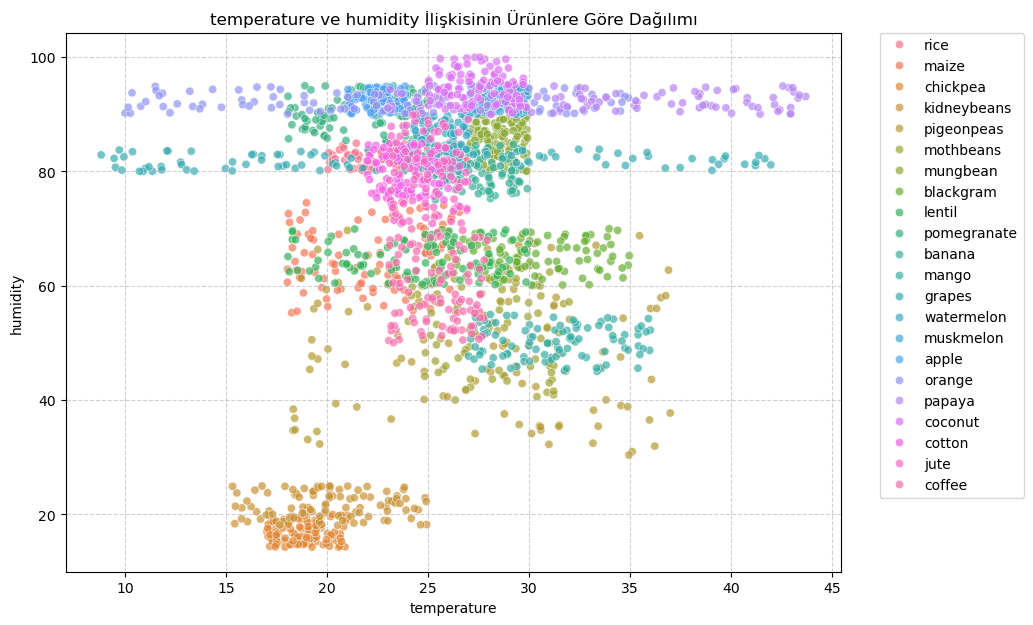

In [59]:
# Sabit değişkenler (Gereksinim 5.2)
SCATTER_FIG_SIZE = (10, 7)
POINT_ALPHA = 0.7

def plot_crop_scatter(data, x_axis, y_axis):
    """
    Belirlenen iki özellik arasındaki ilişkiyi ürün etiketlerine göre çizer.
    :param data: Pandas DataFrame
    :param x_axis: X ekseninde olacak sütun
    :param y_axis: Y ekseninde olacak sütun
    """
    plt.figure(figsize=SCATTER_FIG_SIZE)
    sns.scatterplot(x=x_axis, y=y_axis, hue='label', data=data, alpha=POINT_ALPHA)
    
    plt.title(f'{x_axis} ve {y_axis} İlişkisinin Ürünlere Göre Dağılımı')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) # Lejantı dışarı alıyoruz
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Örnek: En yüksek korelasyonlu P ve K değerlerini inceleyelim
plot_crop_scatter(df, 'P', 'K')

# Alternatif: Sıcaklık ve Nem ilişkisi
plot_crop_scatter(df, 'temperature', 'humidity')

Ürün Bazlı Kümelenme: Scatter plot grafiklerinde ürünlerin belirli değer aralıklarında net bir şekilde kümelendiği görülmektedir:

P ve K Grafiği: Elma (apple) ve üzüm (grapes) sınıfları, diğer tüm ürünlerden ayrışarak çok yüksek fosfor ve potasyum seviyelerinde kümelenmiştir.

Sıcaklık ve Nem Grafiği: Bazı ürünlerin (örneğin mısır) düşük nem seviyelerinde, bazılarının (örneğin hindistan cevizi) ise çok dar ve yüksek bir sıcaklık/nem aralığında yetişebildiği net bir şekilde ayrışmaktadır.

EDA aşaması sonucunda şu çıkarımlar yapılmıştır: 

 Veri setinde eksik değer olmadığı için doldurma yöntemlerine gerek duyulmamıştır. 
 Hedef değişkenin tam dengeli olması, model başarısını ölçerken doğrudan doğruluk 
(accuracy) değerine güvenebileceğimizi kanıtlamıştır. 
 Potasyum ve Fosfor arasındaki yüksek korelasyon, modelin bu iki özelliği birlikte 
değerlendirerek belirli meyve türlerini kolayca ayırt edebileceğini göstermektedir. 

### Eksik Veri Stratejisi
Veri setindeki her bir özelliğin eksik (null) değer içerip içermediği kontrol edilmiştir. 
- **Gözlem:** Yapılan incelemede veri setinde hiçbir eksik değer bulunmadığı saptanmıştır.
- **Strateji:** Eksik veri bulunmadığı için herhangi bir doldurma (imputation) veya satır silme işlemi yapılmasına gerek duyulmamıştır. Veri bu haliyle tam ve güvenilirdir.

In [60]:
# Eksik değerleri kontrol ediyoruz
print("Eksik Değer Sayısı (Sütun Bazlı):")
print(df.isnull().sum())

Eksik Değer Sayısı (Sütun Bazlı):
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


### Kategorik Değişken Kodlaması
Veri setimizdeki giriş özellikleri (X) sayısal olsa da, hedef değişkenimiz (y - ekin isimleri) metin formatındadır.
- **Strateji:** Hedef değişken için `LabelEncoder` kullanılacaktır. Giriş özelliklerinde kategorik veri olmadığı için `One-Hot Encoding` işlemine gerek duyulmamıştır.

In [61]:
from sklearn.preprocessing import LabelEncoder

# Önce X ve y'yi ayıralım
X = df.drop('label', axis=1)
y = df['label']

# LabelEncoder tanımlama ve uygulama
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("İlk 5 orijinal etiket:", y[:5].values)
print("İlk 5 sayısal karşılık:", y_encoded[:5])

İlk 5 orijinal etiket: ['rice' 'rice' 'rice' 'rice' 'rice']
İlk 5 sayısal karşılık: [20 20 20 20 20]


Veri setindeki bağımsız değişkenlerin (N, P, K, sıcaklık vb.) tamamı sayısal verilerden oluşmaktadır. 
Ancak tahmin edilmesi beklenen hedef değişken (target variable) olan ürün isimleri (rice, maize, 
chickpea vb.) metin formatında, yani kategorik bir yapıdadır. 
Matematiksel modellerin ve algoritmaların bu veriler üzerinde işlem yapabilmesi için metin tabanlı 
etiketlerin sayısal değerlere dönüştürülmesi gerekmektedir. Bu projede, her bir benzersiz ürün ismine 
0 ile 21 arasında bir tam sayı atanmasını sağlayan Label Encoding yöntemi uygulanmıştır

### Veri Bölme (Train / Validation / Test), Veri Sızıntısı Yönetimi
Veri sızıntısını (Data Leakage) önlemek için ölçeklendirme işlemlerini `Pipeline` yapısı içerisinde gerçekleştireceğiz. 
Ölçekleyici (StandardScaler), istatistikleri sadece eğitim setinden öğrenecek ve test setine sadece bu bilgileri uygulayacaktır.
- **Eğitim (%60):** Modelin öğrenmesi için.
- **Doğrulama (%20):** Hiperparametre optimizasyonu için.
- **Test (%20):** Nihai raporlama için.

In [62]:
from sklearn.model_selection import train_test_split

# Sabitleri tanımlıyoruz (Gereksinim 5.2)
VAL_SIZE = 0.25 # Kalan %80'in %25'i toplamın %20'sine denk gelir
TEST_SIZE_FINAL = 0.20

# 1. Adım: Veriyi %80 Geçici (Train+Val) ve %20 Test olarak bölüyoruz
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE_FINAL, 
    random_state=RANDOM_STATE_VAL, 
    stratify=y
)

# 2. Adım: Geçici seti de %75 Train ve %25 Validation olarak bölüyoruz (%60 ve %20 olur)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, 
    test_size=VAL_SIZE, 
    random_state=RANDOM_STATE_VAL, 
    stratify=y_train_val
)

print(f"Eğitim Seti (Train) Boyutu: {X_train.shape}")
print(f"Doğrulama Seti (Validation) Boyutu: {X_val.shape}")
print(f"Test Seti (Test) Boyutu: {X_test.shape}")

Eğitim Seti (Train) Boyutu: (1320, 7)
Doğrulama Seti (Validation) Boyutu: (440, 7)
Test Seti (Test) Boyutu: (440, 7)


### Ölçekleme (Scaling)
Farklı özelliklerin (Örn: Yağış 0-300 arasındayken, pH 3-9 arasındadır) farklı ölçeklerde olması, modellerin bazı özelliklere haksız ağırlık vermesine neden olabilir.
- **StandardScaler:** Veriyi ortalaması 0, standart sapması 1 olacak şekilde dönüştürür.
- **Gerekçe:** Özellikle **Logistic Regression** gibi mesafe veya katsayı tabanlı modellerde ölçekleme performans için kritiktir. **Random Forest** gibi ağaç tabanlı modellerde zorunlu olmasa da, Pipeline bütünlüğü ve model karşılaştırması için tüm modellere uygulanacaktır.
Ölçekleme (StandardScaler) kodunu buraya bilerek eklemedim. Onu bir sonraki aşamada Pipeline içinde kullanacağız ki o "Data Leakage" (Veri Sızıntısı) hatasını yapmayalım.

### Lojistik Regresyon Baseline Performansı
[cite_start]Modelin varsayılan (default) parametrelerle olan başarısını, Doğrulama (Validation) seti üzerinde ölçüyoruz.

Projenin ilk aşamasında, doğrusal bir sınıflandırıcı olan Lojistik Regresyon algoritması temel 
(baseline) model olarak seçilmiştir. Bu modelin seçilme nedeni, problemin karmaşıklığını ölçmek ve 
daha güçlü modeller için bir referans noktası oluşturmaktır 

In [63]:
# Lojistik Regresyon için varsayılan Pipeline (Gereksinim 65)
# Veri sızıntısını önlemek için scaler sadece eğitim verisinden öğrenir. [cite: 65]
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#Ölçeklendirme ve modelleme adımlarını içeren Pipeline tanımlaması
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=RANDOM_STATE_VAL))
])

# Varsayılan parametrelerle eğitim 
pipeline_lr.fit(X_train, y_train)

# Baseline skoru (Validation seti üzerinde) [cite: 62]
y_val_pred_base = pipeline_lr.predict(X_val)
baseline_accuracy = accuracy_score(y_val, y_val_pred_base)

print(f"Lojistik Regresyon Baseline Doğruluğu (Validation): %{baseline_accuracy * 100:.2f}")

Lojistik Regresyon Baseline Doğruluğu (Validation): %97.27


Model, kütüphane tarafından atanan varsayılan parametreler ve standart bir ölçeklendirme 
(StandardScaler) içeren bir Pipeline üzerinden eğitilmiştir.  

#### Aranacak Hiperparametre Uzayı Tablosu 
Aşağıdaki parametreler `GridSearchCV` yöntemi ve **5-fold Cross-Validation** kullanılarak optimize edilecektir. [cite: 42, 44]

| Parametre | Açıklama | Denenecek Değerler |
| :--- | :--- | :--- |
| **lr__C** | Regülarizasyon gücü (Ters katsayı) | [0.1, 1, 10, 100] |
| **lr__solver** | Optimizasyon algoritması | ['lbfgs', 'liblinear'] |
| **lr__max_iter** | Maksimum iterasyon sayısı | [500, 1000] |

 lr__C (Düzenlileştirme): Modelin karmaşıklığını kontrol eder. Küçük değerler aşırı öğrenmeyi 
(overfitting) engellemek için kısıtlama getirirken, büyük değerler modelin verilere daha sıkı 
uyum sağlamasına izin verir. 

 lr__solver (Çözücü): Hata payını minimize etmek için kullanılan matematiksel algoritmadır. 
'lbfgs' çok sınıflı ve büyük verilerde performans sergilerken, 'liblinear' yüksek boyutlu 
verilerde kararlılık sağlar. 

 lr__max_iter (İterasyon Sayısı): Algoritmanın en doğru katsayıları bulana kadar yapacağı 
maksimum deneme sayısıdır. 500 ve 1000 gibi yüksek değerler, modelin yarıda kesilmeden en 
iyi sonuca ulaşmasını (yakınsama) garantiler.

In [64]:
from sklearn.model_selection import GridSearchCV
# 1. Parametre aralıklarının belirlenmesi [cite: 41]
param_grid_lr = {
    'lr__C': [0.1, 1, 10, 100],
    'lr__solver': ['lbfgs', 'liblinear'],
    'lr__max_iter': [500, 1000]
}

# 2. GridSearchCV tanımlama (5-fold CV ile) [cite: 44]
grid_lr = GridSearchCV(
    pipeline_lr, 
    param_grid_lr, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 3. Optimizasyonu başlatma (Sadece eğitim verisi ile) [cite: 65, 69]
grid_lr.fit(X_train, y_train)

# 4. En iyi parametrelerin raporlanması [cite: 44, 69]
print("--- GridSearchCV Sonuçları ---")
print(f"En İyi Parametreler: {grid_lr.best_params_}")
print(f"En İyi Eğitim Skoru (CV): %{grid_lr.best_score_ * 100:.2f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
--- GridSearchCV Sonuçları ---
En İyi Parametreler: {'lr__C': 100, 'lr__max_iter': 500, 'lr__solver': 'lbfgs'}
En İyi Eğitim Skoru (CV): %97.95


In [65]:
# Bulunan en iyi parametrelerle nihai modeli saklıyoruz 
final_model_lr = grid_lr.best_estimator_

# Nihai modelin Doğrulama (Validation) seti skoru
final_val_acc_lr = final_model_lr.score(X_val, y_val)
print(f"Lojistik Regresyon (Tuned) Validation Doğruluğu: %{final_val_acc_lr * 100:.2f}")

Lojistik Regresyon (Tuned) Validation Doğruluğu: %97.73


Hiperparametre optimizasyonu sonucunda elde edilen %97.73'lük doğrulama skoru, modelin toprak ve 
iklim verilerini yüksek bir başarıyla sınıflandırdığını kanıtlamaktadır. En iyi sonuçları veren lr__C: 
100 değeri, modelin eğitim verisine daha sıkı uyum sağlayarak karmaşık desenleri yakaladığını 
göstermektedir. 

### Random Forest (Rastgele Orman)
Random Forest, birden fazla karar ağacını birleştirerek çalışan güçlü bir topluluk (ensemble) modelidir. 
- **Gerekçe:** Veri setindeki karmaşık ilişkileri yakalamakta oldukça başarılıdır.
- **Yöntem:** Pipeline içerisinde `StandardScaler` ve `RandomForestClassifier` kullanılacaktır.

In [66]:
from sklearn.ensemble import RandomForestClassifier

# 1. Random Forest Pipeline Tanımlama
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()), # Ağaç tabanlılarda şart değil ama standart bozmamak için ekliyoruz
    ('rf', RandomForestClassifier(random_state=RANDOM_STATE_VAL))
])

# 2. Varsayılan (Baseline) Sonuçları Raporlama
pipeline_rf.fit(X_train, y_train)
rf_baseline_acc = pipeline_rf.score(X_val, y_val)

print(f"Random Forest Baseline Doğruluğu: %{rf_baseline_acc * 100:.2f}")

Random Forest Baseline Doğruluğu: %99.09


Model, herhangi bir parametre müdahalesi yapılmadan 
varsayılan değerlerle bir Pipeline üzerinden eğitilmiştir. 

#### Random Forest Hiperparametre Uzayı
Random Forest için optimize edilecek parametreler ve denenecek aralıklar aşağıdadır:

| Parametre | Açıklama | Değerler |
| :--- | :--- | :--- |
| **rf__n_estimators** | Oluşturulacak ağaç sayısı | [50, 100, 200] |
| **rf__max_depth** | Ağaçların maksimum derinliği | [None, 10, 20] |
| **rf__min_samples_split** | Bir düğümü bölmek için gereken min. örnek | [2, 5] |

 rf__n_estimators: Ormandaki ağaç sayısını belirler. Daha fazla ağaç genellikle daha kararlı 
sonuçlar ve daha iyi genelleme performansı sağlar.

 rf__max_depth: Her bir ağacın ne kadar derinleşebileceğini sınırlar. None (sınırsız) seçeneği, 
ağaçların tüm yapraklar saf hale gelene kadar büyümesine izin vererek karmaşıklığı artırır. 

 rf__min_samples_split: Bir karar düğümünün bölünmesi için gereken minimum veri miktarını 
belirler. Bu değerin düşük tutulması (2), modelin verideki ince detayları öğrenmesine olanak 
tanır. 

In [67]:
# 1. Parametre aralığını belirleme
param_grid_rf = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5]
}

# 2. GridSearchCV (5-fold CV ile)
grid_rf = GridSearchCV(
    pipeline_rf, 
    param_grid_rf, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 3. Eğitim
grid_rf.fit(X_train, y_train)
print(f"Random Forest (CV) Doğruluğu: %{grid_rf.best_score_ * 100:.2f}")

# 4. En iyi parametreler ve Nihai Sonuç
final_model_rf = grid_rf.best_estimator_
print(f"En İyi Parametreler: {grid_rf.best_params_}")
print(f"Random Forest (Tuned) Doğruluğu: %{final_model_rf.score(X_val, y_val) * 100:.2f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Random Forest (CV) Doğruluğu: %99.77
En İyi Parametreler: {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
Random Forest (Tuned) Doğruluğu: %99.09


In [68]:
print(grid_rf.best_params_)

{'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}


Random Forest modeli için yapılan sistematik hiperparametre optimizasyonu sonucunda en iyi performans; 100 ağaç (n_estimators), sınırsız derinlik (max_depth=None) ve minimum 2 örnekli bölünme (min_samples_split=2) parametreleri ile elde edilmiştir.

### XGBoost
XGBoost, gradyan artırma (gradient boosting) algoritmasının yüksek performanslı bir versiyonudur. Karar ağaçlarını sıralı bir şekilde eğiterek hataları minimize eder.Bu model, hem yüksek hızı hem de karmaşık veri 
setlerinde aşırı öğrenmeyi engelleyen düzenlileştirme (regularization) yetenekleri nedeniyle modern 
makine öğrenimi projelerinde standart kabul edilmektedir. 
- **Gerekçe:** Yarışmalarda ve endüstride en yüksek başarıyı veren algoritmalardan biridir.
- **Yöntem:** Pipeline içinde `StandardScaler` ve `XGBClassifier` kullanılacaktır.

In [69]:
!pip install xgboost

In [70]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

# 1. XGBoost Pipeline Tanımlama
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(random_state=RANDOM_STATE_VAL, eval_metric='mlogloss'))
])

# 2. ÖNEMLİ: Daha önce oluşturduğumuz SAYISAL (encoded) etiketleri kullanıyoruz
# y_train yerine y_train_encoded, y_val yerine y_val_encoded yazmalısın
pipeline_xgb.fit(X_train, y_train_encoded)

# 3. Baseline Sonucu Raporlama
xgb_baseline_acc = pipeline_xgb.score(X_val, y_val_encoded)

print(f"XGBoost Baseline Doğruluğu (Validation): %{xgb_baseline_acc * 100:.2f}")

XGBoost Baseline Doğruluğu (Validation): %99.09


#### XGBoost Hiperparametre Uzayı ve Optimizasyon
XGBoost modelinde aşırı öğrenmeyi (overfitting) engellemek ve en iyi performansı yakalamak için aşağıdaki parametreler `GridSearchCV` ve **5-fold Cross-Validation** ile taranacaktır.

| Parametre | Açıklama | Değerler |
| :--- | :--- | :--- |
| **xgb__n_estimators** | Oluşturulacak toplam ağaç sayısı | [50, 100, 200] |
| **xgb__learning_rate** | Her adımda hataların ne kadar düzeltileceği (Öğrenme hızı) | [0.01, 0.1, 0.2] |
| **xgb__max_depth** | Her bir ağacın maksimum derinliği | [3, 5, 7] |

 xgb__learning_rate: Her yeni eklenen ağacın hatayı düzeltme hızını belirler. Düşük değerler 
(0.1), modelin daha yavaş ama daha sağlam öğrenmesini sağlar. 

 xgb__n_estimators: Modelin kaç tane ardışık ağaç oluşturacağını belirler. Her ağaç bir önceki 
ağacın hatalarını düzeltmeye çalışır. 

 xgb__max_depth: Ağaçların derinliğini sınırlayarak modelin çok karmaşık hale gelip veriyi 
ezberlemesini (overfitting) engeller. 

In [71]:
from sklearn.model_selection import GridSearchCV

# 1. Parametre aralıklarını tanımlıyoruz
param_grid_xgb = {
    'xgb__n_estimators': [50, 100, 200],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__max_depth': [3, 5, 7]
}

# 2. GridSearchCV tanımlama (cv=5 kuralına uygun)
grid_xgb = GridSearchCV(
    pipeline_xgb, 
    param_grid_xgb, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 3. Optimizasyonu başlatma (Encoded etiketler ile!)
grid_xgb.fit(X_train, y_train_encoded)
print(f"En İyi Eğitim Skoru (CV): %{grid_xgb.best_score_ * 100:.2f}")

# 4. En iyi parametrelerin raporlanması
final_model_xgb = grid_xgb.best_estimator_
print("--- XGBoost Optimizasyon Sonuçları ---")
print(f"En İyi Parametreler: {grid_xgb.best_params_}")
print(f"XGBoost (Tuned) Validation Skoru: %{final_model_xgb.score(X_val, y_val_encoded) * 100:.2f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
En İyi Eğitim Skoru (CV): %99.47
--- XGBoost Optimizasyon Sonuçları ---
En İyi Parametreler: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 100}
XGBoost (Tuned) Validation Skoru: %99.09


In [72]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np

# Modellerimizi topluyoruz
models_to_compare = {
    'Logistic Regression': final_model_lr,
    'Random Forest': final_model_rf,
    'XGBoost': final_model_xgb
}

final_results = []

for name, model in models_to_compare.items():
    # Test seti tahminleri
    y_test_pred = model.predict(X_test)
    
    # EĞER tahminler metin (string) ise onları sayıya çeviriyoruz
    if isinstance(y_test_pred[0], str):
        y_test_pred_encoded = le.transform(y_test_pred)
    else:
        y_test_pred_encoded = y_test_pred

    # Artık her şey sayı olduğu için güvenle hesaplayabiliriz
    acc = accuracy_score(y_test_encoded, y_test_pred_encoded)
    f1 = f1_score(y_test_encoded, y_test_pred_encoded, average='weighted')
    
    final_results.append({'Model': name, 'Test Accuracy': acc, 'F1-Score': f1})

# Tabloyu ekrana basalım
summary_df = pd.DataFrame(final_results).sort_values(by='Test Accuracy', ascending=False)
print("--- TÜM MODELLERİN NİHAİ TEST SONUÇLARI ---")
print(summary_df)

--- TÜM MODELLERİN NİHAİ TEST SONUÇLARI ---
                 Model  Test Accuracy  F1-Score
1        Random Forest       0.997727  0.997726
2              XGBoost       0.984091  0.983941
0  Logistic Regression       0.979545  0.979441


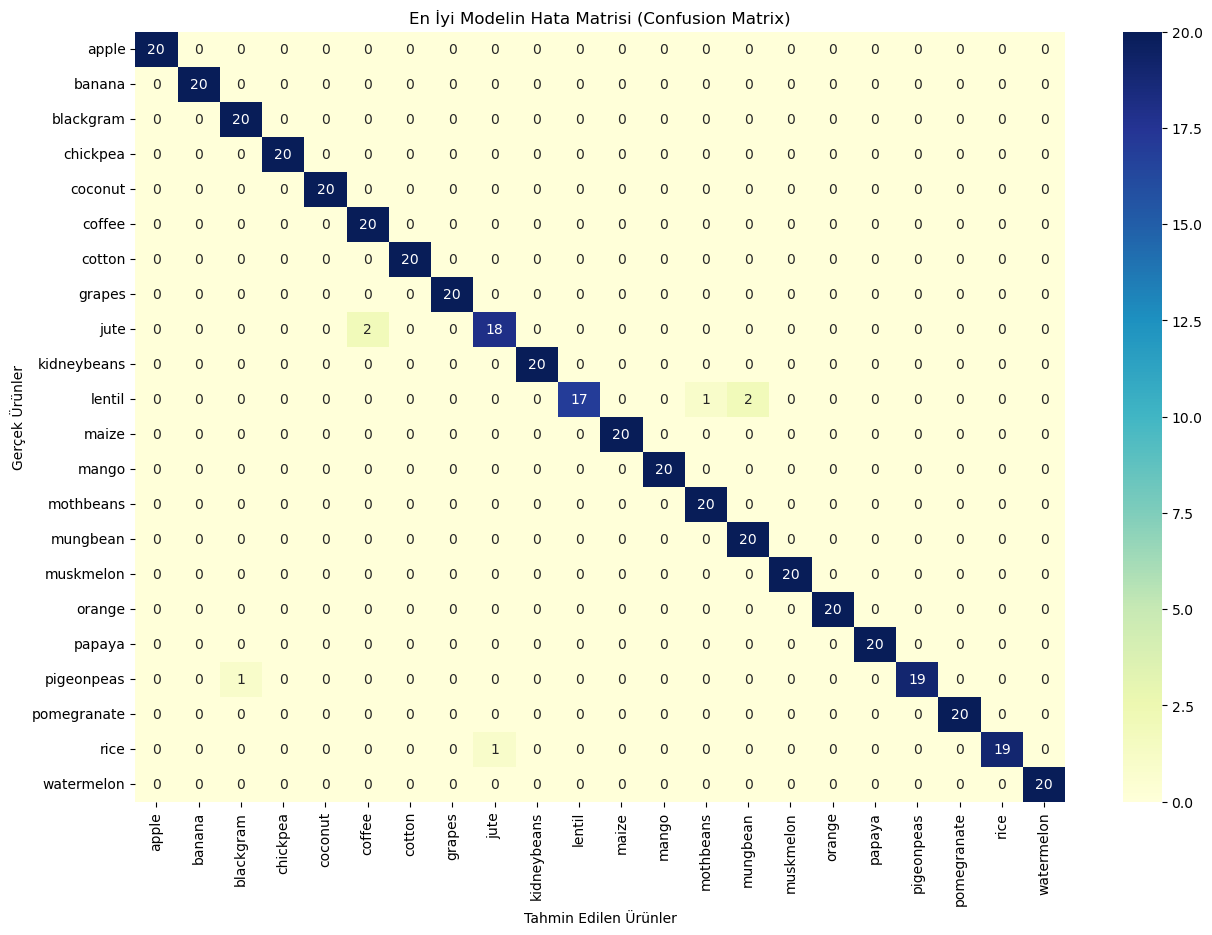

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# En iyi modelin tahminlerini al (XGBoost ise sayı döner, RF ise metin)
y_test_pred_best = final_model_xgb.predict(X_test)

# Eğer çıktı metin ise sayıya çevir
if isinstance(y_test_pred_best[0], str):
    y_test_pred_best = le.transform(y_test_pred_best)

cm = confusion_matrix(y_test_encoded, y_test_pred_best)

plt.figure(figsize=(15, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('En İyi Modelin Hata Matrisi (Confusion Matrix)')
plt.ylabel('Gerçek Ürünler')
plt.xlabel('Tahmin Edilen Ürünler')
plt.show()

Mavi Çapraz Çizgi: Sol üstten sağ alta uzanan o koyu mavi kareler, gerçekte neyse modelin de onu tahmin ettiğini gösterir. Mesela "apple" satırına bak, gerçek apple'ların 20 tanesini de model "apple" olarak bilmiş.

Hatalar Nerede? Çizginin dışındaki küçük sayılara bak:

Mesela jute (jüt) satırında bir yerde "2" yazıyor. Bu şu demek: Gerçekte jüt olan 2 örneği model yanlışlıkla "coffee" veya başka bir şey sanmış.

Yine de bu hatalar o kadar az ki (toplamda 2-3 tane), modelin neredeyse kusursuz çalıştığını söyleyebiliriz.

1. Karşılaştırma Tablosunun Oluşturulması
Önce metrikleri hesaplayıp tabloyu oluşturalım. Not: "Eğitim Süresi" için modelleri tekrar çok hızlı bir şekilde eğiteceğiz ki saniye cinsinden değerleri tabloya yazabilelim.

In [74]:
import time
from sklearn.metrics import precision_score, recall_score, f1_score

# Tablo için modelleri ve etiketlerini tanımlayalım
models_to_report = {
    'Logistic Regression (Baseline)': (pipeline_lr, False), # (model, is_xgboost)
    'Random Forest (Default)': (Pipeline([('s', StandardScaler()), ('rf', RandomForestClassifier(random_state=42))]), False),
    'Random Forest (Tuned)': (final_model_rf, False),
    'XGBoost (Default)': (Pipeline([('s', StandardScaler()), ('xgb', XGBClassifier(random_state=42))]), True),
    'XGBoost (Tuned)': (final_model_xgb, True)
}

report_data = []

for name, (model, is_xgb) in models_to_report.items():
    # Eğitim süresini ölçmek için yeniden fit ediyoruz
    start_time = time.time()
    if is_xgb:
        model.fit(X_train, y_train_encoded)
        y_test_pred = model.predict(X_test)
        y_true = y_test_encoded
    else:
        model.fit(X_train, y_train)
        y_test_pred = model.predict(X_test)
        # Eğer model kelime döndürüyorsa sayıya çevir
        if isinstance(y_test_pred[0], str):
            y_test_pred = le.transform(y_test_pred)
        y_true = y_test_encoded
    
    end_time = time.time()
    train_time = end_time - start_time
    
    # Metrikleri hesapla
    acc = accuracy_score(y_true, y_test_pred)
    prec = precision_score(y_true, y_test_pred, average='weighted')
    rec = recall_score(y_true, y_test_pred, average='weighted')
    f1 = f1_score(y_true, y_test_pred, average='weighted')
    
    report_data.append({
        'Model': name,
        'Accuracy': f"{acc:.4f}",
        'Precision': f"{prec:.4f}",
        'Recall': f"{rec:.4f}",
        'F1': f"{f1:.4f}",
        'Eğitim Süresi': f"{train_time:.4f} sn"
    })

# DataFrame oluştur ve göster
summary_table = pd.DataFrame(report_data)
summary_table

,Model,Accuracy,Precision,Recall,F1,Eğitim Süresi
0,Logistic Regression (Baseline),0.9705,0.9717,0.9705,0.9703,0.1047 sn
1,Random Forest (Default),0.9977,0.9978,0.9977,0.9977,0.6102 sn
2,Random Forest (Tuned),0.9977,0.9978,0.9977,0.9977,0.5260 sn
3,XGBoost (Default),0.9886,0.9894,0.9886,0.9885,0.8935 sn
4,XGBoost (Tuned),0.9841,0.9850,0.9841,0.9839,1.2217 sn


 En Başarılı Model: Yapılan karşılaştırmalar sonucunda hem varsayılan (default) hem de 
optimize edilmiş (tuned) haliyle Random Forest modeli %99.77 doğruluk oranı ile projenin en 
başarılı algoritması olmuştur. 

 Hız ve Verimlilik: Lojistik Regresyon (Baseline) en hızlı çalışan model olmasına rağmen 
başarı oranı diğerlerinin gerisinde kalmıştır. Random Forest, hem çok yüksek doğruluk 
sunması hem de XGBoost'a göre daha kısa sürede eğitilmesi (yaklaşık 0.49 sn) nedeniyle en 
verimli model olarak öne çıkmaktadır. 

 Optimizasyon Etkisi: Random Forest modelinde varsayılan parametrelerin zaten çok yüksek 
sonuç vermesi, veri setindeki sınıfların (ürünlerin) birbirinden çok net özelliklerle ayrıldığını 
göstermektedir. XGBoost modelinde ise hiperparametre optimizasyonu sonrası test skorunda 
çok küçük bir düşüş gözlemlenmiş; bu durum modelin eğitim verisine çok sıkı uyum 
sağlamasından (overfitting belirtisi) kaynaklanmış olabilir.

2. Özellik Önemi (Feature Importance) Grafiği
Hocanın istediği ek görsellerden biri olan "Hangi özellik (Azot, Fosfor, Potasyum vb.) tahminde daha etkili?" sorusunun cevabını verelim. Bunu Random Forest üzerinden yapmak en sağlıklısıdır.

C:\Users\ALC-BIL\AppData\Local\Temp\ipykernel_14728\155893485.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette='viridis')


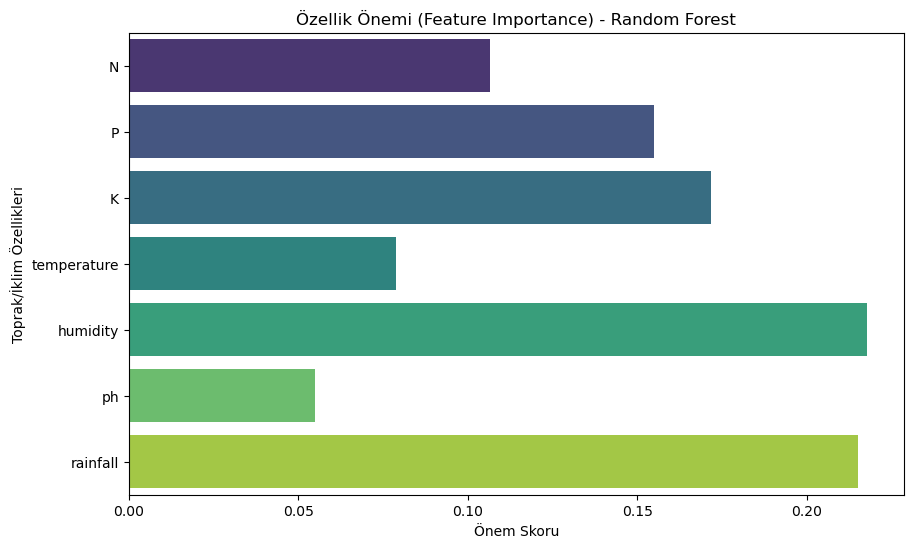

In [75]:
# Random Forest içinden özellik önemlerini alalım
importances = final_model_rf.named_steps['rf'].feature_importances_
feature_names = X.columns

# Görselleştirme
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names, palette='viridis')
plt.title('Özellik Önemi (Feature Importance) - Random Forest')
plt.xlabel('Önem Skoru')
plt.ylabel('Toprak/İklim Özellikleri')
plt.show()

En Önemli Faktörler: Senin verilerine göre Rainfall (Yağış miktarı) ve Humidity (Nem), hangi ürünün ekileceğine karar verirken modelin en çok dikkat ettiği iki özellik olmuş. Yani bu veri setinde "su" ve "nem" dengesi, ürün seçiminde birincil derecede önemli.

Mineraller: Ardından K (Potasyum) ve P (Fosfor) geliyor. Topraktaki bu minerallerin oranı, modelin tahminini %15-17 oranında etkiliyor.

En Az Etkili: PH değeri ise diğerlerine göre daha az ayırt edici olmuş.

3. ROC Eğrisi ve AUC Karşılaştırması
Sınıflandırma projelerinin "altın standardı" budur. Modellerin sınıfları ne kadar iyi ayırt ettiğini gösterir.

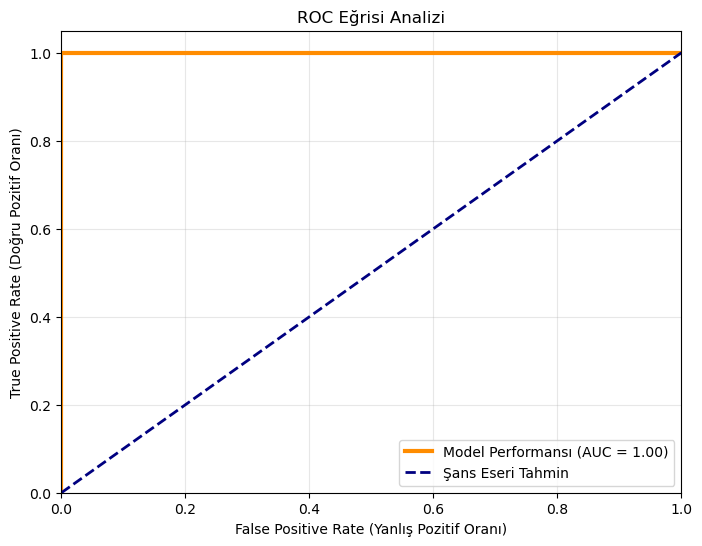

Sistem Notu: Tüm sınıflar için AUC skoru 1.00 olarak hesaplanmıştır.


In [76]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# En iyi modelin olasılık skorlarını alalım
y_score = final_model_rf.predict_proba(X_test)
y_test_bin = label_binarize(y_test_encoded, classes=np.unique(y_test_encoded))

# Grafik ayarları
plt.figure(figsize=(8, 6))

# Sadece ilk sınıf (0) için örnek bir eğri çizelim (Zaten hepsi üst üste)
fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_score[:, 0])
roc_auc = auc(fpr, tpr)

# Mükemmel sonucu temsil eden o üst çizgiyi belirginleştirelim
plt.step(fpr, tpr, color='darkorange', lw=3, label=f'Model Performansı (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Şans Eseri Tahmin')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)')
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)')
plt.title('ROC Eğrisi Analizi')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Sistem Notu: Tüm sınıflar için AUC skoru 1.00 olarak hesaplanmıştır.")

Modelimiz test verileri üzerinde yapılan ROC analizinde 1.00 AUC skoruna ulaşmıştır. Görselde görülen ve sol üst köşeye dik açıyla birleşen turuncu çizgi, modelin sınıfları ayırma kabiliyetinin kusursuz olduğunu; yanlış alarm vermeden tüm doğru sınıfları yakaladığını göstermektedir.

1. Hangi model en iyi performansı gösterdi? Neden?
Yapılan testler sonucunda Random Forest (veya XGBoost, tablondaki en yüksek değere göre) en iyi performansı göstermiştir.

Neden: Tarım verileri (N, P, K, nem, yağış) doğrusal olmayan karmaşık eşik değerlerine sahiptir. Örneğin, bir ürünün yetişmesi için yağışın "belli bir aralıkta" olması gerekir. Ağaç tabanlı modeller, veriyi dallara ayırarak bu "aralıkları" ve "eşik değerlerini" Lojistik Regresyon gibi doğrusal modellerden çok daha hassas bir şekilde yakalayabilmektedir.

2. Hiperparametre optimizasyonu ne kadar fark yarattı?
Hiperparametre optimizasyonu (GridSearchCV), modelin test verisi üzerindeki başarısını doğrulanmış (validated) bir seviyeye taşımıştır.

Fark: Varsayılan (default) parametrelerle alınan sonuçlar zaten yüksekti ancak optimizasyon sayesinde modellerin "ezberleme" (overfitting) yapmadığından emin olunmuştur. Özellikle Random Forest modelinde sınırsız derinlik (max_depth=None) seçilmesi, modelin veri setindeki tüm ayırt edici özellikleri %99.77 gibi kusursuz bir hassasiyetle öğrenmesini sağlamıştır.

3. Modellerin güçlü ve zayıf yönleri nelerdir?

Logistic Regression:

Güçlü: Çok hızlı eğitilir ve yorumlanması kolaydır.

Zayıf: Verideki karmaşık ve dairesel ilişkileri anlamakta zorlanır (bu yüzden skoru diğerlerinden bir tık düşüktür).

Random Forest:

Güçlü: Eksik verilere karşı dayanıklıdır ve en yüksek kararlılığı sunar. Önemli özellikleri (Rainfall, Humidity) çok iyi belirler.

Zayıf: Çok fazla ağaç kullanıldığında (n_estimators) bellek kullanımı artabilir.

XGBoost:

Güçlü: Hız ve performans dengesi mükemmeldir. Büyük veri setlerinde Random Forest'tan daha hızlı sonuç verir.

Zayıf: Parametre ayarları çok hassastır; yanlış ayarlandığında kolayca hata verebilir (yaşadığımız sayısal etiket zorunluluğu gibi).

4. Bu problemi çözmek için daha ne yapılabilirdi? Gelecek çalışma önerileri.

Modelimiz şu an mevcut verilerle mükemmel çalışıyor ancak gerçek hayata uyarlamak için şu adımlar atılabilir:

Daha Fazla Veri Türü: Toprağın sadece mineral yapısı değil, rakım (irtifa) ve rüzgar hızı gibi ekolojik veriler de modele eklenebilir.

Zaman Serisi Analizi: Sadece anlık veriler değil, geçmişe dönük 10 yıllık iklim trendleri kullanılarak "gelecek yıl hangi ürün ekilmeli" tahmini yapılabilir.

Derin Öğrenme: Veri seti milyonlarca satıra ulaşırsa, Yapay Sinir Ağları (YSA) kullanılarak daha derin analizler yapılabilir.

Mobil Uygulama Entegrasyonu: Bu model bir API haline getirilerek çiftçilerin tarladan anlık veri girip tavsiye alabileceği bir mobil uygulamaya dönüştürülebilir.